<a href="https://colab.research.google.com/github/brissacalderon/brissacalderon.github.io/blob/main/Data_Science_Salary_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Prepartion

Dataset Description:  
This dataset containes the details of the AI, ML, Data Science Salary (2020- 2025).

## l. Variable Description

*   work_year: The year in which the salary was paid.
*   experience_level: The level of experience required for the job
*   employment_type: The type of employment for the role
*   job_title: The job role or position held during the year.
*   salary: The total gross salary paid to the employee.
*   salary_currency: The currency in which the salary was paid
*   salary_in_usd: The salary converted to U.S. dollars for comparison purposes.
*   employee_residence: The employees country of residence
*   remote_ratio: The proportion of remote work
*   company_location: The country where the company is located.
*   company_size: The size of the company

Target Variable: salary_in_usd





















## ll. Problems

1. What patterns exist among high-paying jobs?

2. Has the average salary changed over the years (work_year)?

3. Given a specific job_title, experience_level, and company_location, what is the expected salary_in_usd for 2026?

4. Does company size (small, medium, large) influence employee salary?

5. Does reaching a Senior level (SE) lead to a statistically significant increase in salary compared to other experience levels?

6. What are the 3 natural 'Economic Profiles' of the 2026 data market, and which one offers the best balance of salary and remote flexibility?


## lll. Data Cleaning

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from collections import Counter
from sklearn import preprocessing

In [ ]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read data #salaries is the dataframe
salaries = pd.read_csv('https://drive.google.com/uc?export=download&id=1hwMbdPx1U2vPn5OlFFA-z0L4nwuWwHAN')

In [ ]:
#Show the head rows of the data frame
salaries.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Customer Success Manager,57000,EUR,60000,NL,50,NL,L
1,2025,SE,FT,Engineer,165000,USD,165000,US,0,US,M
2,2025,SE,FT,Engineer,109000,USD,109000,US,0,US,M
3,2025,SE,FT,Applied Scientist,294000,USD,294000,US,0,US,M
4,2025,SE,FT,Applied Scientist,137600,USD,137600,US,0,US,M


In [ ]:
# Show the tail rows of a data frame
salaries.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
88579,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
88580,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
88581,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
88582,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
88583,2021,SE,FT,Data Scientist,7000000,INR,94665,IN,50,IN,L


In [ ]:
#Show the shape of the dataframe
salaries.shape

(88584, 11)

In [ ]:
# Examine the number of rows and cols
salaries.shape

(88584, 11)

In [ ]:
# Examine variable type
salaries.dtypes

,0
work_year,int64
experience_level,object
employment_type,object
job_title,object
salary,int64
salary_currency,object
salary_in_usd,int64
employee_residence,object
remote_ratio,int64
company_location,object


In [ ]:
#Filter out extreme outliers
salaries = salaries[salaries['salary_in_usd'] < 600000]

In [ ]:
# Change categorical variables to "category"
salaries['experience_level'] = salaries['experience_level'].astype('category')
salaries['employment_type'] = salaries['employment_type'].astype('category')
salaries['employee_residence'] = salaries['employee_residence'].astype('category')
salaries['company_location'] = salaries['company_location'].astype('category')
salaries['company_size'] = salaries['company_size'].astype('category')
salaries['job_title'] = salaries['job_title'].astype('category')

In [ ]:
# Display all categorical variables
salaries.select_dtypes(include=['category'])

,experience_level,employment_type,job_title,employee_residence,company_location,company_size
0,MI,FT,Customer Success Manager,NL,NL,L
1,SE,FT,Engineer,US,US,M
2,SE,FT,Engineer,US,US,M
3,SE,FT,Applied Scientist,US,US,M
4,SE,FT,Applied Scientist,US,US,M
...,...,...,...,...,...,...
88579,SE,FT,Data Scientist,US,US,L
88580,MI,FT,Principal Data Scientist,US,US,L
88581,EN,FT,Data Scientist,US,US,S
88582,EN,CT,Business Data Analyst,US,US,L


In [ ]:
# Display all numeric variables
salaries.select_dtypes(include=['number'])

,work_year,salary,salary_in_usd,remote_ratio
0,2025,57000,60000,50
1,2025,165000,165000,0
2,2025,109000,109000,0
3,2025,294000,294000,0
4,2025,137600,137600,0
...,...,...,...,...
88579,2020,412000,412000,100
88580,2021,151000,151000,100
88581,2020,105000,105000,100
88582,2020,100000,100000,100


In [ ]:
# Examine missing values in each column
salaries.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [ ]:
# Examine the total number of duplicate records
salaries.duplicated().sum()

np.int64(44314)

In [ ]:
# Drop columns
salaries = salaries.drop(columns=['salary_currency', 'salary'])

# Exploratory Data Analysis


## l. Explore Numeric Variables

In [ ]:
# Show the statistics of a numeric variable: salary_in_usd
salaries['salary_in_usd'].describe()

,salary_in_usd
count,88477.000000
mean,156921.923302
std,71165.919661
min,15000.000000
25%,106000.000000
50%,146050.000000
75%,198000.000000
max,599947.000000


In [ ]:
# Obtain median
salaries['salary_in_usd'].median()

146050.0

In [ ]:
# Obtain the variance, standard deviation, and range of a numeric varaible: salary_in_usd
print("variance: ", salaries['salary_in_usd'].var(), "standard deviation: ", salaries['salary_in_usd'].std(), "range: ", salaries['salary_in_usd'].min(), salaries['salary_in_usd'].max())

variance:  5064588121.202659 standard deviation:  71165.91966104745 range:  15000 599947


Text(0.5, 1.0, 'Boxplot of Salary_in_USD in the salaries data set')

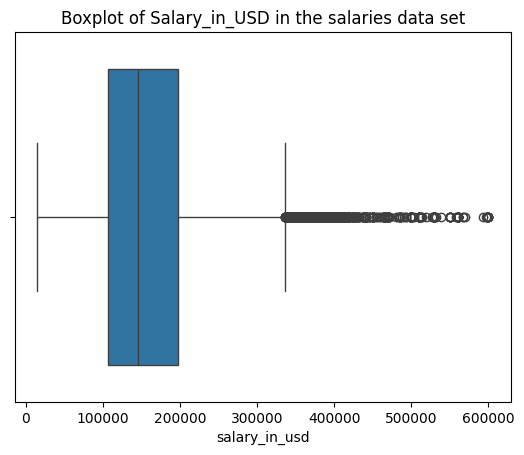

In [ ]:
# Show box plot
snsplot = sns.boxplot(x='salary_in_usd', data = salaries)
snsplot.set_title("Boxplot of Salary_in_USD in the salaries data set")

In [ ]:
# IQR of salary_in_usd variable
IQR = salaries['salary_in_usd'].quantile(0.75) - salaries['salary_in_usd'].quantile(0.25)
print("IQR:", IQR)

IQR: 92000.0


In [ ]:
# Find the employee(s) with the highest salary_in_usd
salaries[salaries['salary_in_usd'] == salaries['salary_in_usd'].max()]

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
2803,2025,SE,FT,Analytics Engineer,599947,US,0,US,M


In [ ]:
# Find the employee(s) with the lowest salary_in_usd
salaries[salaries['salary_in_usd'] == salaries['salary_in_usd'].min()]

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
82850,2022,MI,FT,Business Intelligence Developer,15000,GH,100,GH,M
85061,2020,EX,FT,Staff Data Analyst,15000,NG,0,CA,M
87689,2021,EN,FT,Machine Learning Developer,15000,TH,100,TH,L
87986,2022,EN,FT,Data Analyst,15000,ID,0,ID,L


Text(0.5, 1.0, 'Histogram of Salary_in_USD')

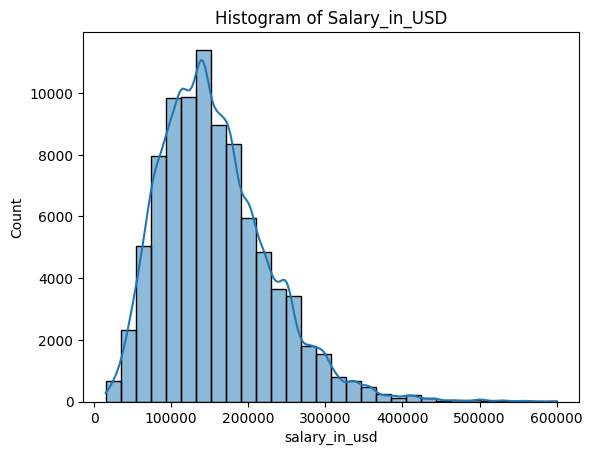

In [ ]:
# Histogram of a numeric variable: salary_in_usd
snsplot = sns.histplot(x='salary_in_usd', data = salaries, bins=30, kde=True)
snsplot.set_title("Histogram of Salary_in_USD")

In [ ]:
#Correlation of work_year, salary_in_us, remote_ratio
salaries.corr(numeric_only=True)

,work_year,salary_in_usd,remote_ratio
work_year,1.000000,0.029098,-0.120978
salary_in_usd,0.029098,1.000000,-0.068503
remote_ratio,-0.120978,-0.068503,1.000000


Text(0.5, 1.0, 'heatmap of correlation matrix')

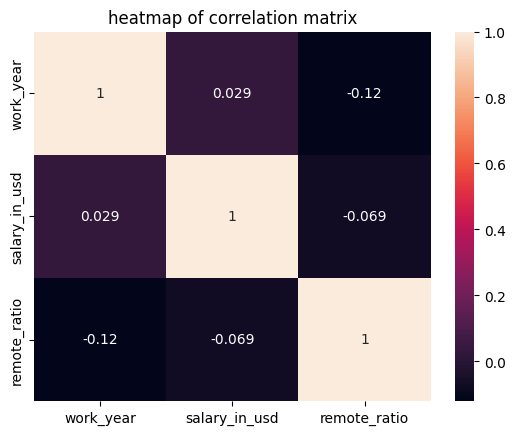

In [ ]:
# Show heatmap
snsplot = sns.heatmap(salaries.corr(numeric_only=True), annot=True)
snsplot.set_title("heatmap of correlation matrix")

This is a weak correlation because it is close to 0 and most numbers are negative

## ll. Explore Categorical Varibale

In [ ]:
# Show the statistics of a catgorical variable: experience_level
salaries['experience_level'].describe()

,experience_level
count,88477
unique,4
top,SE
freq,51540


In [ ]:
# Counts of experience_level counts
salaries['experience_level'].value_counts()

,count
experience_level,
SE,51540
MI,26703
EN,8376
EX,1858


In [ ]:
# Show the proportion of experience_level counts
salaries['experience_level'].value_counts(normalize=True)

,proportion
experience_level,
SE,0.582524
MI,0.301807
EN,0.094669
EX,0.021000


Text(0.5, 1.0, 'countpldt of Experience in the dataScience data set')

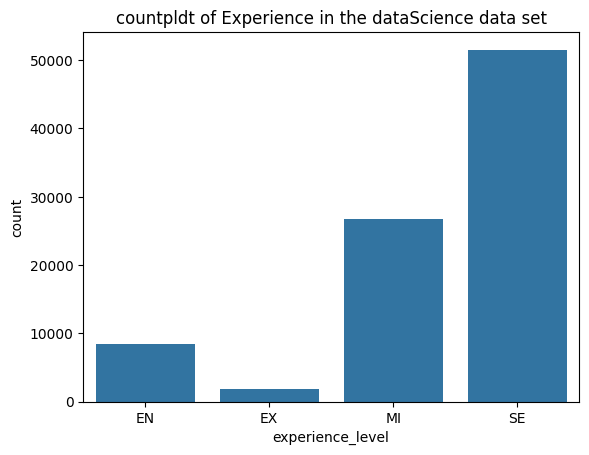

In [ ]:
# Plot a categorical variable: experience_level
snsplot = sns.countplot(x='experience_level', data=salaries)
snsplot.set_title("countpldt of Experience in the dataScience data set")

- You can see that Senior-level is the **mode** because it's the most common group in our data. It’s also the highest level in this specific comparison, while Executive-level is the lowest or least frequent group

## lll. Relationships between multiple variables

Text(0.5, 1.0, 'Average Salary by Experience Level and Company Size')

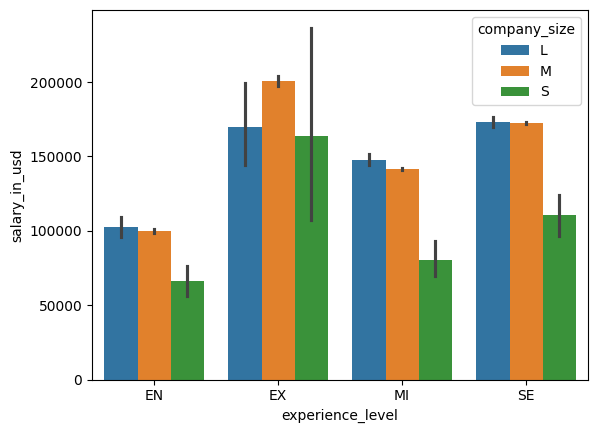

In [ ]:
# Countplot two numeric variables: experience_level and salary_in_usd
sns.barplot(x='experience_level', y='salary_in_usd', hue='company_size', data=salaries)
snsplot.set_title("Average Salary by Experience Level and Company Size")

In [ ]:
# Create groups based on Experience variable
grouped = salaries.groupby('experience_level')['salary_in_usd'].mean()

/tmp/ipykernel_30272/3933913436.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = salaries.groupby('experience_level')['salary_in_usd'].mean()


In [ ]:
# Describe function on each group
salaries.groupby('experience_level')['salary_in_usd'].describe()

/tmp/ipykernel_30272/1630020566.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salaries.groupby('experience_level')['salary_in_usd'].describe()


,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,8376.0,99932.547755,54074.088058,15000.0,62824.0,87900.0,125825.0,560000.0
EX,1858.0,200004.092573,76556.550462,15000.0,145000.0,190000.0,244975.0,550000.0
MI,26703.0,141756.146425,67792.048248,15000.0,93300.0,130000.0,175900.0,598952.0
SE,51540.0,172487.854210,68342.686475,15809.0,123700.0,161200.0,210000.0,599947.0


Text(0.5, 1.0, 'Average Salary by Experience Level')

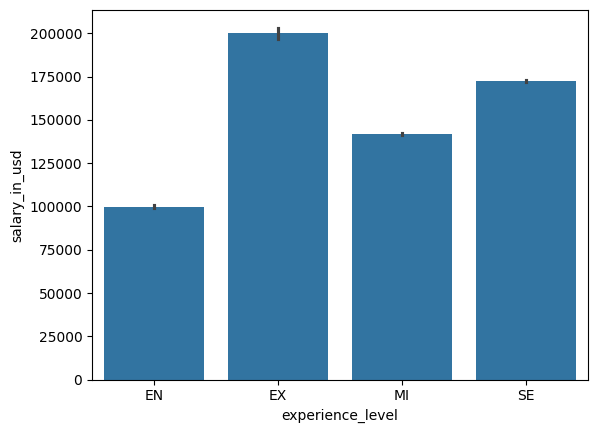

In [ ]:
# Barplot of experience_level and salary_in_usd
sns.barplot(x='experience_level', y='salary_in_usd', data=salaries)
snsplot.set_title("Average Salary by Experience Level")

Examine the reltionship between work_year and salary_in_usd

In [ ]:
# Create groups based on Work Year variable
grouped = salaries.groupby('work_year')['salary_in_usd'].mean()

<Axes: xlabel='work_year', ylabel='salary_in_usd'>

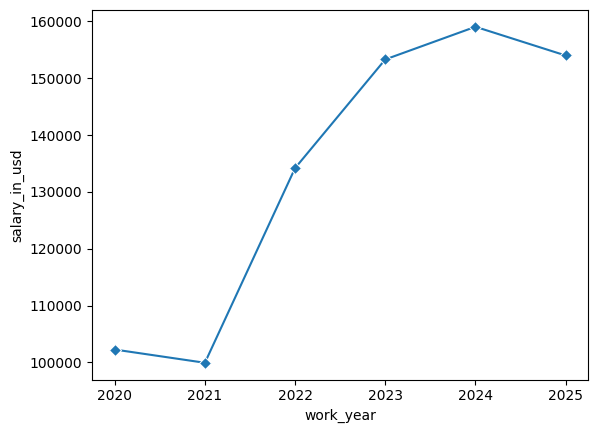

In [ ]:
# Line chart of salaries changed over time.
yearly_avg = salaries.groupby('work_year', as_index=False)['salary_in_usd'].mean()
sns.lineplot(x='work_year', y='salary_in_usd', data=yearly_avg, marker='D')

- The average salary in 2025 remains substantially higher than it was at the start of the recorded period in 2020.

In [ ]:
# Group job_title
salaries.groupby('job_title')

/tmp/ipykernel_30272/3895234631.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salaries.groupby('job_title')


In [ ]:
# Show groups and size
salaries.groupby('job_title').size()

/tmp/ipykernel_30272/2755362194.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salaries.groupby('job_title').size()


,0
job_title,
AI Architect,163
AI Data Engineer,2
AI Data Scientist,8
AI Developer,123
AI Engineer,846
...,...
Tech Lead,18
Technical Lead,112
Technical Specialist,4


In [ ]:
# Group employee_residence
salaries.groupby('employee_residence')

/tmp/ipykernel_30272/34883016.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salaries.groupby('employee_residence')


In [ ]:
# Show groups and size
salaries.groupby('employee_residence').size()

/tmp/ipykernel_30272/1282275664.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salaries.groupby('employee_residence').size()


,0
employee_residence,
AD,1
AE,5
AM,10
AR,66
AS,1
...,...
VE,2
VN,7
XK,2


Text(0.5, 1.0, 'Average Salary by Experience Level')

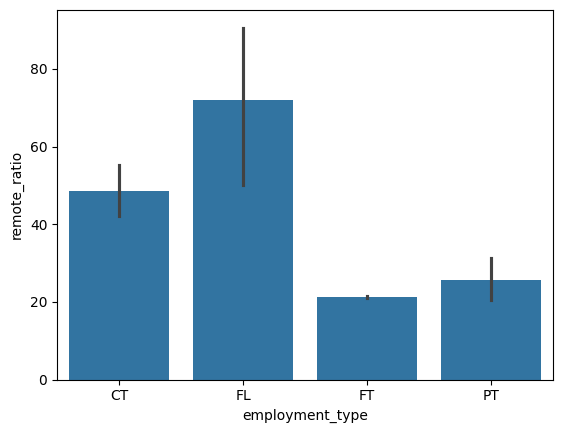

In [ ]:
#Barplot for employment_type and remote_ratio
sns.barplot(x='employment_type', y='remote_ratio', data=salaries)
snsplot.set_title("Average Salary by Experience Level")

In [ ]:
# Percentile of Top 25% high paying jobs
threshold = salaries['salary_in_usd'].quantile(0.25)
high_paying = salaries[salaries['salary_in_usd']>= threshold]


In [ ]:
# Show results: job_title, employment_type, company_size
print("Top Job Titles:\n", high_paying["job_title"].value_counts().head())
print("\nEmployment Type\n", high_paying["employment_type"].value_counts())
print("\nCompany Size", high_paying["company_size"].value_counts())

Top Job Titles:
 job_title
Data Scientist               10448
Software Engineer             8651
Data Engineer                 8105
Machine Learning Engineer     5981
Engineer                      4305
Name: count, dtype: int64

Employment Type
 employment_type
FT    66305
CT       92
PT       46
FL        0
Name: count, dtype: int64

Company Size company_size
M    64347
L     2029
S       67
Name: count, dtype: int64


- Most common job title is Data Scientist with 10, 448
- The largest group of professionals are Full Time (FT)
- The majority belong to Medium size companies

# Data Mining

### I. Data Processing

In [ ]:
# Dummy variables expect for target varaible: salary_in_usd
salaries_d = pd.get_dummies(salaries, columns=['company_size','company_location','employee_residence','experience_level', 'employment_type', 'job_title'], drop_first=True, dtype=int)
salaries_d

,work_year,salary_in_usd,remote_ratio,company_size_M,company_size_S,company_location_AE,company_location_AM,company_location_AR,company_location_AS,company_location_AT,...,job_title_Statistical Programmer,job_title_Statistician,job_title_System Engineer,job_title_Systems Engineer,job_title_Tableau Developer,job_title_Tech Lead,job_title_Technical Lead,job_title_Technical Specialist,job_title_Technical Writer,job_title_Technology Integrator
0,2025,60000,50,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025,165000,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2025,109000,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2025,294000,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2025,137600,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88579,2020,412000,100,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88580,2021,151000,100,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88581,2020,105000,100,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88582,2020,100000,100,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Partition the data
target = salaries_d['salary_in_usd']
predictors = salaries_d.drop(['salary_in_usd'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0  )
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(61933, 505) (26544, 505) (61933,) (26544,)


Text(0.5, 1.0, 'Histrogram of Expense in the Training Dataset')

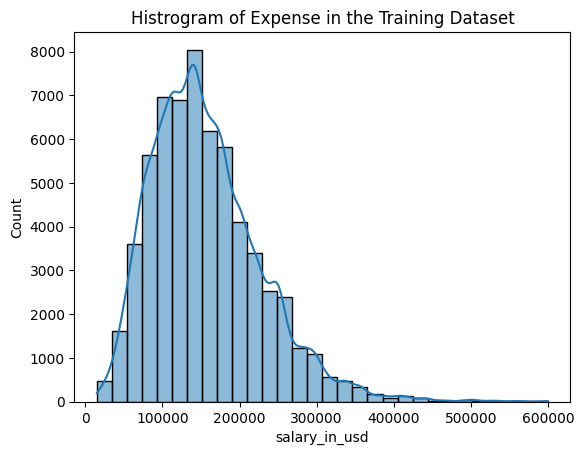

In [ ]:
# Examine the distribution of target variable for training data set
snsplot = sns.histplot(data = target_train, bins=30, kde=True)
snsplot.set_title("Histrogram of Expense in the Training Dataset")

Text(0.5, 1.0, 'Histrogram of Expense in the Test Dataset')

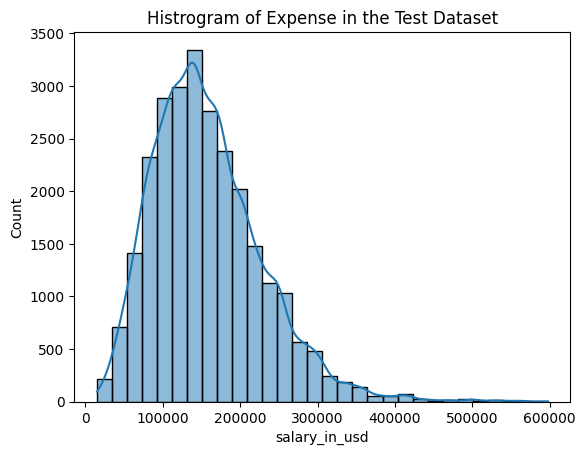

In [ ]:
# Examine the distribution of target variable for testing data set
snsplot = sns.histplot(data = target_test, bins=30, kde=True)
snsplot.set_title("Histrogram of Expense in the Test Dataset")

# Numeric Prediction--

## I. Simple linear regression

In [ ]:
# Instead of 'experience_level', use the numeric dummy column
X = sm.add_constant(predictors_train[['experience_level_SE']])
model1 = sm.OLS(target_train, X).fit()


In [ ]:
# Show model summary
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     4446.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        00:53:42   Log-Likelihood:            -7.7773e+05
No. Observations:               61933   AIC:                         1.555e+06
Df Residuals:                   61931   BIC:                         1.555e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.349e+05    

R-squared for the Simple Regression is 0.067 (6.7%). This means seniority alone only explains about 7% of why people are paid differently. The other 93% is missing which is why it's pretty low.

P-value is 0.00 which tells us that there is a 0% chance of this being a random occurrence, the Seniority Bonus is completely validated

In [ ]:
# Make predictions on testing data
prediction_on_test = model1.predict(sm.add_constant(predictors_test[['experience_level_SE']]))

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
RMSE = root_mean_squared_error (target_test, prediction_on_test)
print ("MAE:", MAE)
print ("RMSE:", RMSE)

MAE: 52953.211451770054
RMSE: 68690.17061421453


- To figure out exactly how much being a 'Senior' adds to a salary boost, I turned the experience_level column into a numeric dummy variable. In this model, 1 means the person is a Senior (SE) and 0 means they are not. This let me run a simple regression to find the 'Senior Premium.' You can easily swap out the experience_level_SE variable for others (like experience_level_EX) if you want to find the specific salary jump for a different level.

## II. Multiple Regression

In [ ]:
# Multiple linear regression model with all predictors
X = sm.add_constant(predictors_train)
model1 = sm.OLS(target_train, X).fit()

In [ ]:
# Show model summary
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     62.82
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        00:53:52   Log-Likelihood:            -7.6833e+05
No. Observations:               61933   AIC:                         1.538e+06
Df Residuals:                   61490   BIC:                         1.542e+06
Df Model:                         442                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [ ]:
# Make predictions on testing data
prediction_on_test = model1.predict(sm.add_constant(predictors_test))

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
RMSE = root_mean_squared_error(target_test, prediction_on_test)
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 45043.39660744077
RMSE: 59349.122362753245


- I used a Multiple Regression model to predict what salaries will look like in 2026. Unlike the simple model, this one looks at job_title, experience_level, and company_location all at the same time. This is important because it gives a much more accurate prediction by accounting for how different roles and locations impact pay differently, rather than just looking at one factor.

- R-squared of 0.311 (31%) whic means that we went from explaining only 7% of salaries with just 'Seniority' to explaining 31% by looking at the whole picture.

- Since the P-value for the Constant is 0.034, we can be confident that our mathematical starting point isn't just a random guess. It means the foundation of our 2026 forecast correct.

# Clustering Analysis

In [ ]:
# Apply minmax normalization
min_max_scaler = preprocessing.MinMaxScaler()
salaries_normalized = pd.DataFrame(min_max_scaler.fit_transform (salaries_d))
salaries_normalized.columns = salaries_d.columns
salaries_normalized

,work_year,salary_in_usd,remote_ratio,company_size_M,company_size_S,company_location_AE,company_location_AM,company_location_AR,company_location_AS,company_location_AT,...,job_title_Statistical Programmer,job_title_Statistician,job_title_System Engineer,job_title_Systems Engineer,job_title_Tableau Developer,job_title_Tech Lead,job_title_Technical Lead,job_title_Technical Specialist,job_title_Technical Writer,job_title_Technology Integrator
0,1.0,0.076930,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.256433,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.160698,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.476966,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.209592,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88472,0.0,0.678694,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88473,0.2,0.232500,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88474,0.0,0.153860,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88475,0.0,0.145312,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### I. Clustering Model 1 & 2

In [ ]:
#Build a clustering model with n_clusters = 2. Set random_state=0.
model1 = KMeans(n_clusters=2, random_state=0)
model1.fit(salaries_normalized)

KMeans(n_clusters=2, random_state=0)

In [ ]:
# Generate the cluster labels
model1.labels_

array([0, 1, 1, ..., 0, 0, 1], dtype=int32)

In [ ]:
#Show cluster size
Counter(model1.labels_)

Counter({np.int32(0): 36937, np.int32(1): 51540})

### II. Clustering Model 3

In [ ]:
# Build a clustering model with n_clusters = 2. Set random_state=0.
model2 = KMeans(n_clusters=3, random_state=0)
model2.fit(salaries_normalized)

KMeans(n_clusters=3, random_state=0)

In [ ]:
# Show cluster centroids
pd.DataFrame({'cluster 1':salaries_d[model1.labels_==0].mean(axis=0), 'cluster 2':salaries_d[model1.labels_==1].mean(axis=0)})

,cluster 1,cluster 2
work_year,2024.076157,2024.004598
salary_in_usd,135202.019709,172487.854210
remote_ratio,17.352519,24.090997
company_size_M,0.956439,0.974622
company_size_S,0.003926,0.001339
...,...,...
job_title_Tech Lead,0.000000,0.000349
job_title_Technical Lead,0.000000,0.002173
job_title_Technical Specialist,0.000000,0.000078
job_title_Technical Writer,0.000244,0.000194


In [ ]:
# Generate the cluster labels
model2.labels_

array([2, 1, 1, ..., 0, 0, 2], dtype=int32)

In [ ]:
# Show cluster centroids
pd.DataFrame({'cluster 1':salaries_d[model2.labels_==0].mean(axis=0),'cluster 2':salaries_d[model2.labels_==1].mean(axis=0),'cluster 3':salaries_d[model2.labels_==2].mean(axis=0)})

,cluster 1,cluster 2,cluster 3
work_year,2024.096482,2024.005603,2023.963295
salary_in_usd,142446.480545,176863.588912,102313.065341
remote_ratio,16.885073,23.877280,23.329545
company_size_M,0.960066,0.975123,0.948864
company_size_S,0.001491,0.000611,0.015568
...,...,...,...
job_title_Tech Lead,0.000000,0.000337,0.000227
job_title_Technical Lead,0.000000,0.001980,0.002045
job_title_Technical Specialist,0.000000,0.000042,0.000227
job_title_Technical Writer,0.000248,0.000211,0.000114


- I’m using a clustering analysis to group employees together based on similarities in their salary, remote work ratios, and work year. Instead of just looking at labels like 'Job Title,' the K- means finds hidden patterns in the data to create its own groups (clusters). This helps me see which types of roles naturally fall into 'low,' 'middle,' or 'high' pay categories regardless of what their official title is

Text(0.5, 1.0, 'Elbow Test')

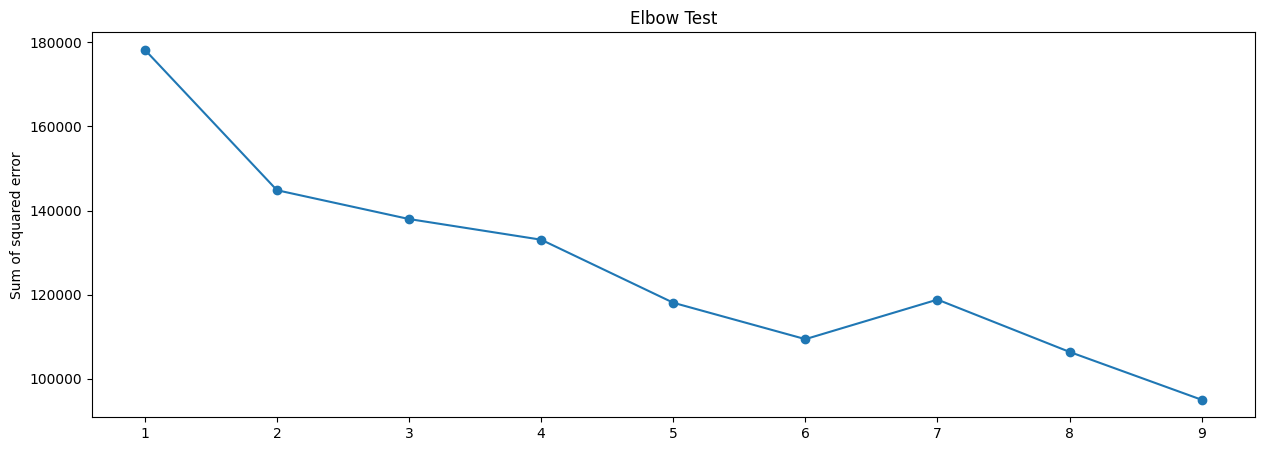

In [ ]:
#Elbow method for optimal number of clusters
Sum_of_squared_error = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(salaries_normalized)
    Sum_of_squared_error.append(kmeans.inertia_)

fig = plt.figure(figsize=(15, 5))
plt.scatter(range(1, 10), Sum_of_squared_error)
plt.plot(range(1, 10), Sum_of_squared_error)
plt.ylabel('Sum of squared error')
plt.title('Elbow Test')

I used the Elbow Method to determine the optimal number of clusters. By plotting the Sum of Squared Errors against different values of k, I identified the 'elbow' at k=5. This ensures that our 2026 market segments are statistically distinct without over-complicating the model.

# Research Probelms

## Problem 1

1.) What patterns exist among high-paying jobs?

- The most common are Data Scientist, Software Engineer, Data Engineer, and Machine Learning Engineer, showing that high salaries are concentrated in technical and data related fields.

  In terms of employment type, most types are held by full- time employees, followed by contract professionals, while part-time and freelance types are much less common.

  Additionally, high-paying jobs are primarily gound in the medium and large companies, suggesting that larger organizations tend to offer higher compensation.

## Problem 2

2.) Has the average salary changed over the years (work_year)?

- The average salary in 2020 started at just over 100,000 and a very slight dip in 2021.From 2021 you can see an aggressive increase of nearly 160,000 in 2024.

  After reaching its highest point in 2025, it slightly declined around $155,000. So we can determine that salary has changed since 2020.

## Problem 3

3.) Given a specific job_title, experience_level, and company_location, what is the expected salary_in_usd for 2026?

- To predict the 2026 salary for a Senior AI Data Engineer in the US, I used a Multiple Linear Regression model. Even though the mathematical 'Constant' starts at a negative value, it balances out once we add the growth trend for the year 2026 and Senior Level bonus.


- Constant (-1.76M) + (Yearly Coef 941.43 × 2026) + Job Title (-44k) + Seniority (+43k) + Location (+7k) = $145,601.

- The 2026 salary for a Senior AI Data Engineer in the US is **$146,601**


Formula:

Expected Salary (2026) = Predicted Salary = Constant + (Year Coefficient × 2026) + Job Title Coefficient + Experience Level Coefficient + Location Coefficient

## Problem 4

4.) Does company size (small, medium, large) influence employee level salary?

- From the countplot we can see that the company size significantly influences employee salary, though the impact varies depending on the experience level.

  For example, the "Small Company" across almost all experience levels-Entry (EN), Mid (MI), and Senior (SE), the green bars for small companies consistently offer the lowest average salaries.

  The plot demonstrates that moving from a small company to a medium or large one typically results in a substantial salary increase, regardless of your career stage.

## Problem 5

5.) To what extent does achieving Senior-level status influence salary outcomes in the data industry?

- Based on a Simple Linear Regression R^2 = 0.067, reaching a Senior level (SE) provides a statistically significant p < 0.001 average salary boost of $37,360  to the annual salary compared to the baseline (Entry/Mid levels). However, the low R-squared suggests that seniority is only one small part of the total compensation picture.

## Problem 6

6.) What are the 3 natural 'Economic Profiles' of the 2026 data market, and which one offers the best balance of salary and remote flexibility?

1.) Cluster 1: The "Entry/Mid-Level Professional" Profile

Average Salary: ~$119,918

Remote Ratio: 21.18%

Profile: This group has the lowest average salary of the three and a moderate level of remote flexibility.

2.) Cluster 2: The "High-Value/Specialized" Profile

Average Salary: ~$176,780

Remote Ratio: 23.40%

Profile: This represents the top earners in the market. This group also has the highest remote ratio, suggesting that high-demand specialized roles command both top pay and the best flexibility.

3.) Cluster 3: The "Stable Intermediate" Profile

Average Salary: ~$142,709

Remote Ratio: 17.56%

Profile: This group sits in the middle for salary but actually has the lowest remote flexibility of the three.